#### "Missing" here means: Sentinel-2 acquisition existed, BUT it did not satisfy the chosen clear-cropland threshold.

## Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [17]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/03_something/Monsoon Observation Gap/data/sylhet_aman_observations_2022_2024.csv")

## Primary Validity Threshold

In [18]:
PRIMARY_THRESHOLD = 50

## Create Validity Column

In [19]:
df_3d = df.copy()

df_3d["valid_observation"] = (
    df_3d["clear_pct"] >= PRIMARY_THRESHOLD
)

## Count Total Acquisition, Valid Observation and Unavailable Observation

In [20]:
total_opportunities = len(df_3d)
valid_observations = (
    df_3d["valid_observation"]
    .sum()
)
missing_observations = (
    total_opportunities
    - valid_observations
)

print(f"Total Opportunities: {total_opportunities}")
print(f"Valid Observations: {valid_observations}")
print(f"Missing Observations: {missing_observations}")

Total Opportunities: 126
Valid Observations: 47
Missing Observations: 79


## Calculate Observation Avalibility, Observation Loss

In [21]:
observation_availability = (
    valid_observations
    / total_opportunities
    * 100
)

observation_loss = (
    missing_observations
    / total_opportunities
    * 100
)

## Create Summary Table

In [23]:
observed_missing_summary = pd.DataFrame({

    "threshold": [
        PRIMARY_THRESHOLD
    ],

    "total_acquisition_opportunities": [
        total_opportunities
    ],

    "valid_observations": [
        valid_observations
    ],

    "unavailable_observations": [
        missing_observations
    ],

    "observation_availability_pct": [
        observation_availability
    ],

    "observation_loss_pct": [
        observation_loss
    ]

})

print("\n============================================================")
print("PART 3D — OBSERVED vs. MISSING NDVI")
print("============================================================")

print(
    observed_missing_summary
)




PART 3D — OBSERVED vs. MISSING NDVI
   threshold  total_acquisition_opportunities  valid_observations  \
0         50                              126                  47   

   unavailable_observations  observation_availability_pct  \
0                        79                     37.301587   

   observation_loss_pct  
0             62.698413  


## Valid NDVI Observation

In [25]:
valid_ndvi = df_3d[
    df_3d["valid_observation"]
].copy()

# Sort chronology
valid_ndvi = (
    valid_ndvi
    .sort_values("date")
    .reset_index(drop=True)
)

## Plot Observed NDVI Through Time

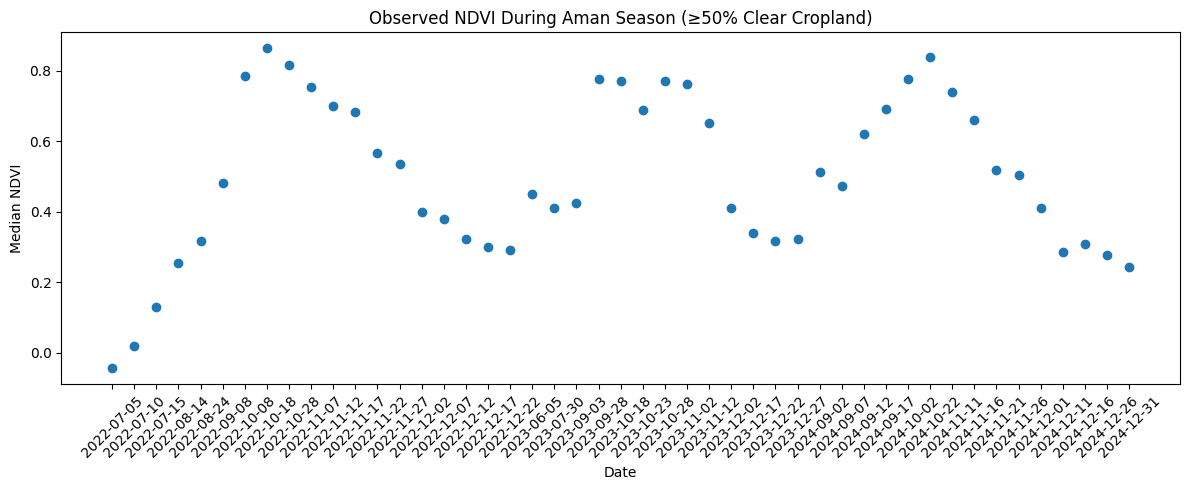

In [26]:
plt.figure(figsize=(12, 5))

plt.scatter(
    valid_ndvi["date"],
    valid_ndvi["ndvi_median"]
)

plt.xlabel("Date")
plt.ylabel("Median NDVI")
plt.title(
    f"Observed NDVI During Aman Season "
    f"(≥{PRIMARY_THRESHOLD}% Clear Cropland)"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Threshold Sensivity Summary

In [27]:
VALID_THRESHOLDS = [50,60,70,80,90]

threshold_results = []

for threshold in VALID_THRESHOLDS:

    valid_count = (
        df["clear_pct"] >= threshold
    ).sum()

    unavailable_count = (
        total_opportunities
        - valid_count
    )

    availability = (
        valid_count
        / total_opportunities
        * 100
    )

    loss = (
        unavailable_count
        / total_opportunities
        * 100
    )

    threshold_results.append({

        "threshold": threshold,

        "total_opportunities":
            total_opportunities,

        "valid_observations":
            valid_count,

        "unavailable_observations":
            unavailable_count,

        "availability_pct":
            availability,

        "observation_loss_pct":
            loss

    })


threshold_summary = pd.DataFrame(
    threshold_results
)


print("\n============================================================")
print("OBSERVATION AVAILABILITY — THRESHOLD SENSITIVITY")
print("============================================================")

print(
    threshold_summary)


OBSERVATION AVAILABILITY — THRESHOLD SENSITIVITY
   threshold  total_opportunities  valid_observations  \
0         50                  126                  47   
1         60                  126                  45   
2         70                  126                  42   
3         80                  126                  38   
4         90                  126                  32   

   unavailable_observations  availability_pct  observation_loss_pct  
0                        79         37.301587             62.698413  
1                        81         35.714286             64.285714  
2                        84         33.333333             66.666667  
3                        88         30.158730             69.841270  
4                        94         25.396825             74.603175  


## Plot Observation Availability By Threshold

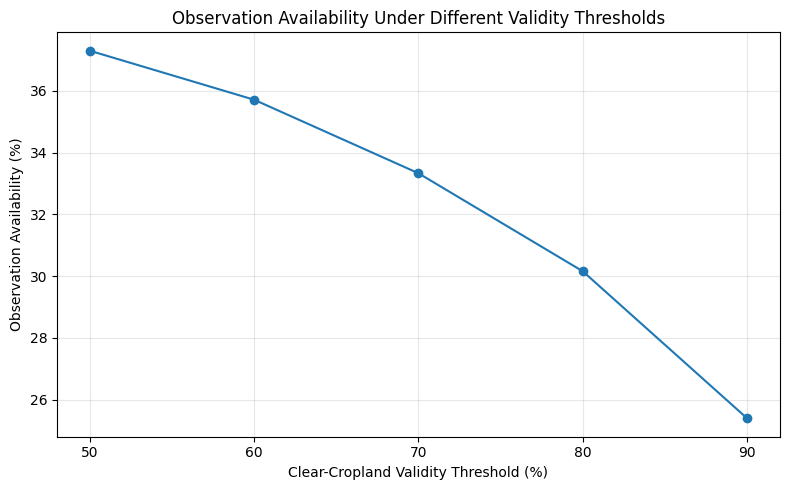

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_summary["threshold"],
    threshold_summary["availability_pct"],
    marker="o"
)

plt.xlabel("Clear-Cropland Validity Threshold (%)")
plt.ylabel("Observation Availability (%)")

plt.title(
    "Observation Availability Under Different "
    "Validity Thresholds"
)

plt.xticks(
    VALID_THRESHOLDS
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Save Result

In [30]:
threshold_summary.to_csv( "04_threshold_sensitivity.csv", index=False )